In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
def get_scheduler(
    t_T = 200,
    jump_len = 10,
    jump_n_sample = 3,
):
    """Obtain a sigma scheduler for the given parameters."""
    jumps = {} 
    for j in range(0, t_T - jump_len, jump_len): 
        jumps[j] = jump_n_sample - 1 

    t = t_T 
    ts = [] 
    while t >= 1: 
        t = t-1 
        ts.append(t)
        if jumps.get(t, 0) > 0: 
            jumps[t] = jumps[t] - 1 
            for _ in range(jump_len): 
                t=t+1 
                ts.append(t) 
    ts.append(-1)
    return ts

In [2]:
sigmas = torch.tensor(np.exp(np.linspace(
            np.log(10),
            np.log(0.001),
            200)), dtype=torch.float32)
step_sizes = sigmas[:-1]**2 - sigmas[1:]**2
step_sizes/sigmas[:-1], torch.sqrt(step_sizes)
torch.sqrt(step_sizes)/(step_sizes/sigmas[:-1])

tensor([3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631, 3.3632, 3.3631, 3.3632,
        3.3632, 3.3632, 3.3631, 3.3632, 3.3631, 3.3632, 3.3632, 3.3631, 3.3632,
        3.3632, 3.3632, 3.3631, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632,
        3.3631, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631, 3.3632, 3.3632, 3.3632,
        3.3632, 3.3631, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632,
        3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632,
        3.3632, 3.3632, 3.3631, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631,
        3.3632, 3.3631, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631, 3.3632,
        3.3632, 3.3632, 3.3631, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631, 3.3632,
        3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632,
        3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631,
        3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3632, 3.3631, 3.3632,
        3.3632, 3.3632, 3.3632, 3.3631, 

In [6]:
sigmas[1:]/sigmas[:-1]

tensor([0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548, 0.9548,
        0.9548, 0.9548, 0.9548, 0.9548, 

In [12]:
sigmas

tensor([1.0000e+01, 9.5477e+00, 9.1159e+00, 8.7036e+00, 8.3099e+00, 7.9341e+00,
        7.5753e+00, 7.2326e+00, 6.9055e+00, 6.5932e+00, 6.2950e+00, 6.0103e+00,
        5.7384e+00, 5.4789e+00, 5.2311e+00, 4.9945e+00, 4.7686e+00, 4.5529e+00,
        4.3470e+00, 4.1504e+00, 3.9627e+00, 3.7835e+00, 3.6123e+00, 3.4490e+00,
        3.2930e+00, 3.1440e+00, 3.0018e+00, 2.8661e+00, 2.7364e+00, 2.6127e+00,
        2.4945e+00, 2.3817e+00, 2.2740e+00, 2.1711e+00, 2.0729e+00, 1.9792e+00,
        1.8897e+00, 1.8042e+00, 1.7226e+00, 1.6447e+00, 1.5703e+00, 1.4993e+00,
        1.4315e+00, 1.3667e+00, 1.3049e+00, 1.2459e+00, 1.1895e+00, 1.1357e+00,
        1.0844e+00, 1.0353e+00, 9.8850e-01, 9.4379e-01, 9.0110e-01, 8.6035e-01,
        8.2143e-01, 7.8428e-01, 7.4881e-01, 7.1494e-01, 6.8261e-01, 6.5173e-01,
        6.2226e-01, 5.9411e-01, 5.6724e-01, 5.4159e-01, 5.1709e-01, 4.9370e-01,
        4.7138e-01, 4.5006e-01, 4.2970e-01, 4.1027e-01, 3.9171e-01, 3.7399e-01,
        3.5708e-01, 3.4093e-01, 3.2551e-

In [11]:
sigmas = torch.tensor(np.exp(np.linspace(
            np.log(10),
            np.log(0.001),
            200)), dtype=torch.float32)
step_sizes = sigmas[:-1]**2 - sigmas[1:]**2
step_sizes/sigmas[:-1], torch.sqrt(step_sizes)
torch.sqrt(sigmas[1:]/sigmas[:-1]*step_sizes)/(step_sizes/sigmas[:-1])

tensor([3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862, 3.2862,
        3.2862, 3.2862, 3.2862, 3.2862, 

In [7]:
times = get_scheduler()
x = torch.rand((10,10))

# for t_last, t_cur in zip(times[:-1], times[1:]):
#     if t_cur < t_last:
#         # Apply reverse denoise
#         x = reverse_denoise(x, t, x_known)
#     else:
#         # Apply forward diffusion
#         x = forward_diffusion(x, t)

(0.0, 958.0)

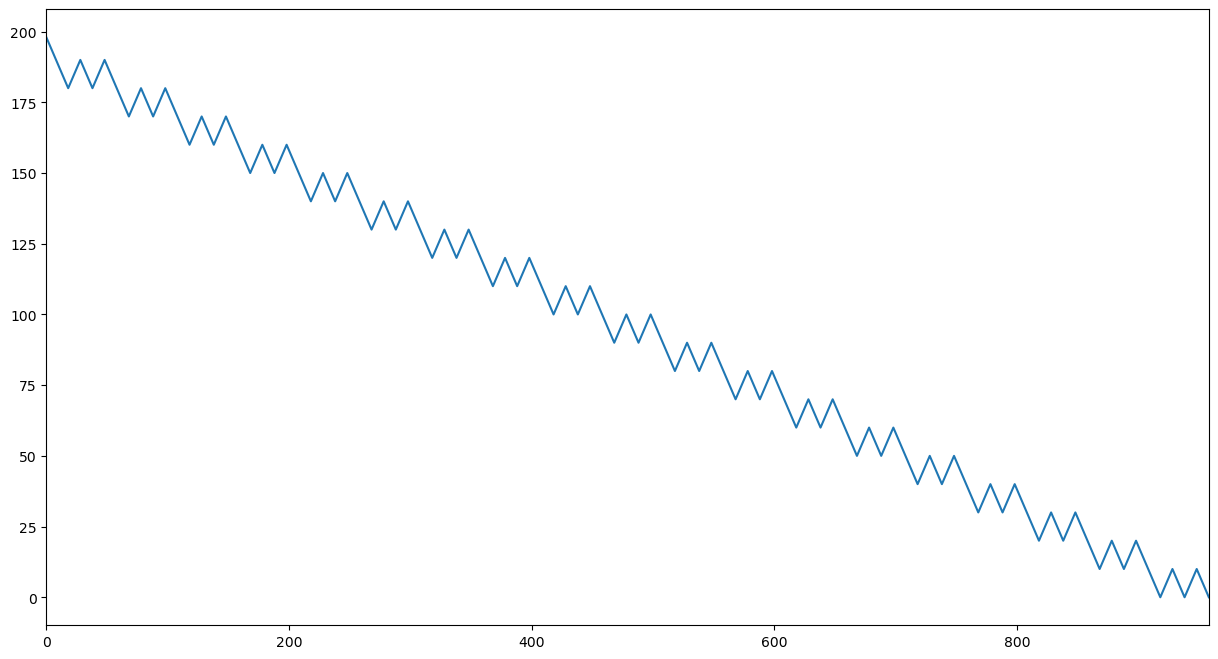

In [8]:
plt.figure(figsize=(15, 8))
plt.plot(times[:-1])
plt.xlim(0, len(times[:-1])-1)

In [170]:
np.max(199 - (np.array(times)+1))

199